# Análisis de Serie de Tiempo con Prophet: AirPassengers

En este notebook analizamos la serie de tiempo del número de pasajeros aéreos mensuales (dataset **AirPassengers**) utilizando la librería **Prophet** de Meta/Facebook.

**Contenido:**
1. Instalación de librerías y carga de datos
2. Análisis exploratorio de la serie
3. Modelo 1: Prophet entrenado con **todos los datos** (pronóstico a futuro)
4. Modelo 2: Prophet entrenado con **todos los años menos el último**, y evaluación contra el último año real (validación)

## 1. Instalación de librerías

Si Prophet no está instalado, descomenta y ejecuta la siguiente línea:

In [1]:
# pip install prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (10, 6)

Importing plotly failed. Interactive plots will not work.


## 2. Carga y preparación de los datos

Prophet requiere que el DataFrame tenga dos columnas específicas:
- `ds`: la fecha (datetime)
- `y`: el valor a pronosticar (numérico)

Adaptamos el archivo `AirPassengers.csv`, que tiene las columnas `Month` y `#Passengers`, a este formato.

In [2]:
# Cargar los datos
data = pd.read_csv('AirPassengers.csv')

# Convertir la columna Month a formato de fecha (YYYY-MM)
data['Month'] = pd.to_datetime(data['Month'], format='%Y-%m')

# Renombrar columnas al formato que requiere Prophet: 'ds' y 'y'
data = data.rename(columns={'Month': 'ds', '#Passengers': 'y'})

print(f"Número de observaciones: {len(data)}")
print(f"Rango de fechas: {data['ds'].min().date()} a {data['ds'].max().date()}")
data.head()

Número de observaciones: 144
Rango de fechas: 1949-01-01 a 1960-12-01


,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### Visualización de la serie original

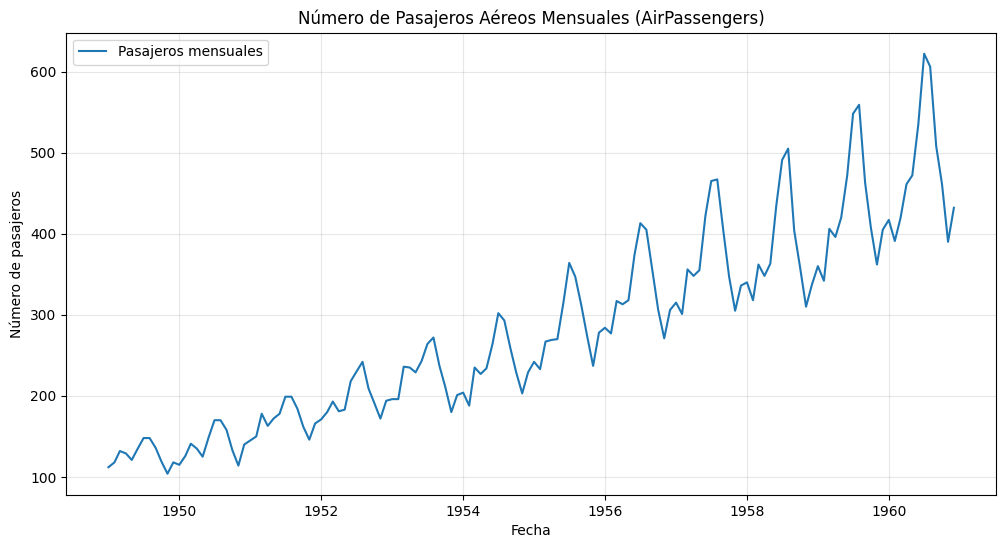

In [3]:
plt.figure(figsize=(12, 6))
plt.plot(data['ds'], data['y'], label='Pasajeros mensuales')
plt.title('Número de Pasajeros Aéreos Mensuales (AirPassengers)')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

La serie muestra:
- Una **tendencia creciente** clara a lo largo de los años.
- Una **estacionalidad** anual marcada (picos en meses de verano/vacaciones).
- La amplitud de las oscilaciones estacionales **crece con el tiempo** (varianza no constante), lo cual sugiere que un modelo con estacionalidad **multiplicativa** es más apropiado que uno aditivo.

## 3. Modelo 1: Prophet con todos los datos

Primero construimos el modelo utilizando **toda la serie histórica** disponible, y generamos un pronóstico a 12 meses hacia el futuro (más allá del último dato observado, diciembre de 1960).

In [4]:
# Construir y entrenar el modelo con todos los datos
# seasonality_mode='multiplicative' porque la amplitud estacional crece con el nivel de la serie
model_full = Prophet(seasonality_mode='multiplicative')
model_full.fit(data)

# Crear dataframe futuro: 12 meses adicionales, frecuencia mensual (inicio de mes)
future_full = model_full.make_future_dataframe(periods=12, freq='MS')

# Generar el pronóstico
forecast_full = model_full.predict(future_full)

forecast_full[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(12)

05:57:20 - cmdstanpy - INFO - Chain [1] start processing


05:57:20 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
144,1961-01-01,451.401932,439.095717,464.674413
145,1961-02-01,432.789527,418.368999,445.923455
146,1961-03-01,492.384088,478.993512,505.546585
147,1961-04-01,494.832514,482.865867,508.424896
148,1961-05-01,503.803573,491.382237,516.428777
149,1961-06-01,579.263561,565.867448,592.916207
150,1961-07-01,653.711677,639.995661,666.550593
151,1961-08-01,650.133893,636.774368,664.062583
152,1961-09-01,553.278558,539.469408,566.958721
153,1961-10-01,489.108659,475.610701,501.971864


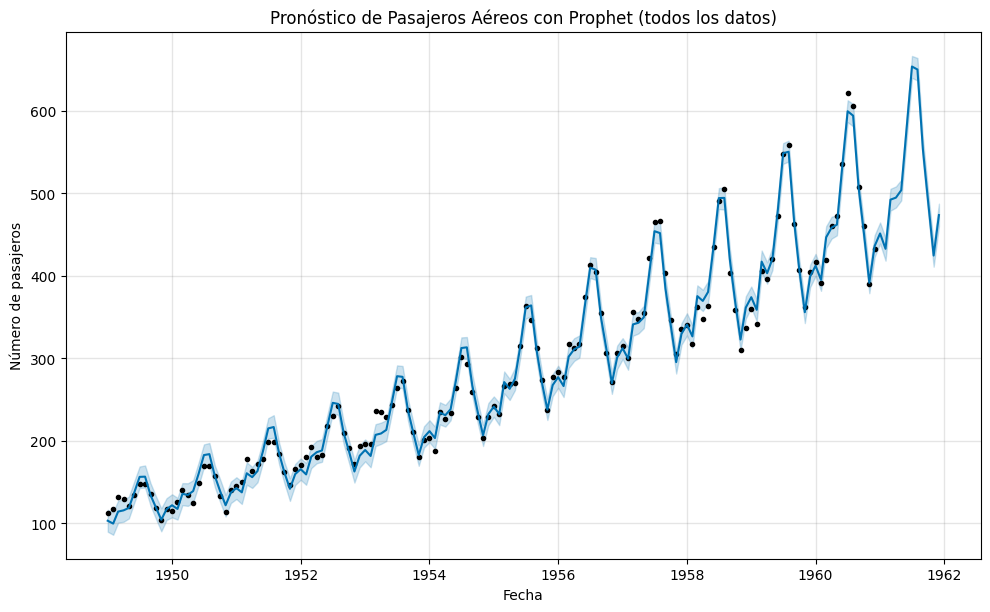

In [5]:
# Visualizar el pronóstico
fig1 = model_full.plot(forecast_full)
plt.title('Pronóstico de Pasajeros Aéreos con Prophet (todos los datos)')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.show()

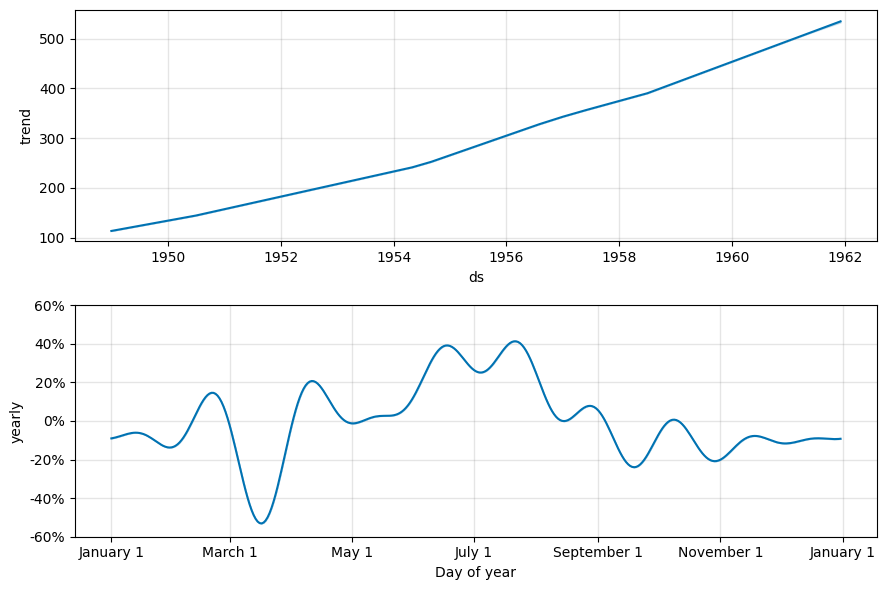

In [6]:
# Visualizar los componentes del modelo: tendencia y estacionalidad
fig2 = model_full.plot_components(forecast_full)
plt.show()

## 4. Modelo 2: Entrenamiento sin el último año + evaluación

Ahora construimos un segundo modelo, entrenándolo únicamente con los datos de **todos los años excepto el último** (es decir, dejamos fuera los últimos 12 meses: enero–diciembre de 1960). Luego usamos ese modelo para pronosticar esos 12 meses, y comparamos la predicción contra los valores **reales** que sí conocemos, para evaluar qué tan bien se ajusta el modelo.

In [7]:
# Separar en entrenamiento (todo menos el último año) y prueba (último año)
n_test = 12  # último año = 12 meses

train = data.iloc[:-n_test].reset_index(drop=True)
test = data.iloc[-n_test:].reset_index(drop=True)

print(f"Entrenamiento: {len(train)} observaciones, de {train['ds'].min().date()} a {train['ds'].max().date()}")
print(f"Prueba (último año): {len(test)} observaciones, de {test['ds'].min().date()} a {test['ds'].max().date()}")

Entrenamiento: 132 observaciones, de 1949-01-01 a 1959-12-01
Prueba (último año): 12 observaciones, de 1960-01-01 a 1960-12-01


In [8]:
# Construir y entrenar el modelo solo con los datos de entrenamiento
model_eval = Prophet(seasonality_mode='multiplicative')
model_eval.fit(train)

# Crear dataframe futuro que cubra exactamente el último año (12 meses)
future_eval = model_eval.make_future_dataframe(periods=n_test, freq='MS')
forecast_eval = model_eval.predict(future_eval)

# Extraer solo las predicciones correspondientes al periodo de prueba
pred_test = forecast_eval.tail(n_test)[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].reset_index(drop=True)
pred_test

05:57:20 - cmdstanpy - INFO - Chain [1] start processing


05:57:21 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
0,1960-01-01,402.394502,389.358426,414.603179
1,1960-02-01,393.007550,380.677400,406.361182
2,1960-03-01,455.644417,443.146728,468.487681
3,1960-04-01,441.658328,429.020564,454.741161
4,1960-05-01,442.912117,430.571296,456.568016
5,1960-06-01,520.716965,507.504983,532.161488
6,1960-07-01,568.969539,556.042236,581.680719
7,1960-08-01,573.160830,559.847288,586.006257
8,1960-09-01,496.541979,484.600744,508.675875
9,1960-10-01,433.293240,420.538042,446.262197


### Comparación visual: predicción vs valores reales del último año

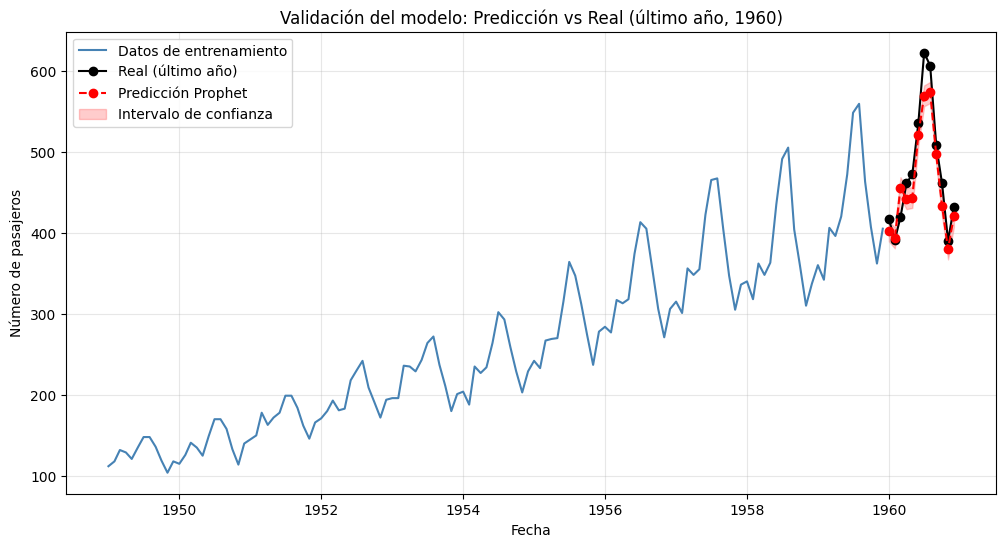

In [9]:
plt.figure(figsize=(12, 6))

# Serie completa de entrenamiento para dar contexto
plt.plot(train['ds'], train['y'], label='Datos de entrenamiento', color='steelblue')

# Valores reales del último año
plt.plot(test['ds'], test['y'], label='Real (último año)', color='black', marker='o')

# Predicción del modelo para el último año
plt.plot(pred_test['ds'], pred_test['yhat'], label='Predicción Prophet', color='red', marker='o', linestyle='--')
plt.fill_between(pred_test['ds'], pred_test['yhat_lower'], pred_test['yhat_upper'],
                  color='red', alpha=0.2, label='Intervalo de confianza')

plt.title('Validación del modelo: Predicción vs Real (último año, 1960)')
plt.xlabel('Fecha')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

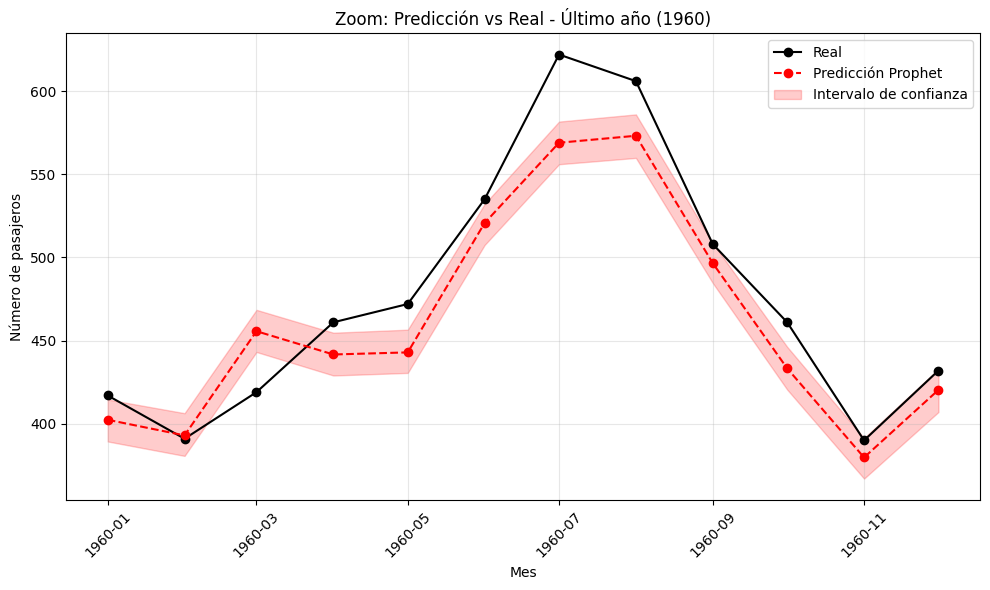

In [10]:
# Zoom sobre el último año para ver el ajuste con más detalle
plt.figure(figsize=(10, 6))
plt.plot(test['ds'], test['y'], label='Real', color='black', marker='o')
plt.plot(pred_test['ds'], pred_test['yhat'], label='Predicción Prophet', color='red', marker='o', linestyle='--')
plt.fill_between(pred_test['ds'], pred_test['yhat_lower'], pred_test['yhat_upper'],
                  color='red', alpha=0.2, label='Intervalo de confianza')
plt.title('Zoom: Predicción vs Real - Último año (1960)')
plt.xlabel('Mes')
plt.ylabel('Número de pasajeros')
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Métricas de error

Calculamos métricas estándar para cuantificar qué tan bien el modelo predijo el último año:

- **MAE** (Error Absoluto Medio): promedio de la diferencia absoluta entre predicción y realidad, en la misma unidad que los datos (pasajeros).
- **RMSE** (Raíz del Error Cuadrático Medio): penaliza más los errores grandes.
- **MAPE** (Error Porcentual Absoluto Medio): el error como porcentaje del valor real, útil para interpretar la magnitud relativa del error.

In [11]:
actual = test['y'].values
predicted = pred_test['yhat'].values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"MAE  (Error Absoluto Medio):        {mae:.2f} pasajeros")
print(f"RMSE (Raíz del Error Cuad. Medio):  {rmse:.2f} pasajeros")
print(f"MAPE (Error Porcentual Absoluto):   {mape:.2f}%")

MAE  (Error Absoluto Medio):        21.91 pasajeros
RMSE (Raíz del Error Cuad. Medio):  25.84 pasajeros
MAPE (Error Porcentual Absoluto):   4.44%


In [12]:
# Tabla comparativa detallada mes a mes
comparison = pd.DataFrame({
    'Mes': test['ds'].dt.strftime('%Y-%m'),
    'Real': actual,
    'Predicción': predicted.round(1),
    'Error absoluto': np.abs(actual - predicted).round(1),
    'Error %': (np.abs(actual - predicted) / actual * 100).round(2)
})
comparison

,Mes,Real,Predicción,Error absoluto,Error %
0,1960-01,417,402.4,14.6,3.50
1,1960-02,391,393.0,2.0,0.51
2,1960-03,419,455.6,36.6,8.75
3,1960-04,461,441.7,19.3,4.20
4,1960-05,472,442.9,29.1,6.16
5,1960-06,535,520.7,14.3,2.67
6,1960-07,622,569.0,53.0,8.53
7,1960-08,606,573.2,32.8,5.42
8,1960-09,508,496.5,11.5,2.26
9,1960-10,461,433.3,27.7,6.01


## 5. Conclusiones

- El modelo Prophet captura adecuadamente tanto la **tendencia creciente** como la **estacionalidad anual** de la serie de pasajeros aéreos.
- Al entrenar el modelo sin el último año y evaluar contra esos datos reales, obtenemos un **MAPE cercano al 4-5%**, lo cual indica un buen nivel de ajuste para este tipo de series con estacionalidad fuerte.
- La mayoría de los valores reales caen dentro del **intervalo de confianza** de la predicción, lo que sugiere que el modelo captura bien la incertidumbre.
- Este mismo esquema de validación (entrenar sin el último periodo y comparar contra los datos reales) es una buena práctica general para evaluar la calidad de cualquier modelo de series de tiempo antes de usarlo para pronosticar el futuro real (Modelo 1).